# Generating & Validating the Synthetic Data

The notebook is organized into two parts. **Part 1** generates a wireless carrier's account base: 24 months of usage, bills, care contacts and churn, two past retention campaigns, care notes written by an LLM, the offer policy the agent follows, and a withheld answer key. **Part 2** validates it: it confirms the market behaves plausibly and that each structure the modeling notebooks are meant to find is present, and not trivially easy to find.

All data is synthetic. Plan names, prices, offers, and results are illustrative. The design is written up in [generator_design.md](generator_design.md).

---

## Part 1 · Generating the Synthetic Data

This part runs in ten steps, each depending only on the ones above it.

1. **Regions & accounts**: 8 regions and about 105,000 accounts, with plan, lines, device, and autopay
2. **Hidden reasons & frailty**: why each account would leave, how prone it is to leave, and which accounts are sleeping dogs
3. **Offers & their effects**: the three retention offers, who accepts them, and how much each lowers churn
4. **Monthly mechanics**: bills, data use, dropped calls, care contacts, and the monthly churn probability
5. **Monthly history**: 24 months of history, including both past campaigns
6. **Scoring snapshot & future months**: tonight's batch at the end of month 24, and months 25–30 for monitoring
7. **Potential outcomes**: each snapshot account's true chance of leaving within 90 days under every offer
8. **Care notes**: about 6,000 notes written by gpt-4o-mini, cached so the notebook reruns without an API key
9. **Offer policy**: the document the agent retrieves from
10. **Export**: model-facing tables and the answer key, written to separate files

In [1]:
# Load Libraries
import asyncio
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit, logit
from IPython.display import display

sys.path.insert(0, str(Path('..') / 'src'))
from retention import data as retention_data

In [2]:
# Synthetic Data Parameters
SEED = 20260921
RNG = np.random.default_rng(SEED)
DATA = Path('synthetic')
DATA.mkdir(parents = True, exist_ok = True)

# Population & Timeline
N_START = 84_000
JOINS_PER_MONTH = 900
N_MONTHS = 24
N_FUTURE = 6
N_REGIONS = 8
WEAK_REGIONS = [2, 5]
SURGE_REGIONS = [1, 6]
SURGE_MONTHS = [16, 17, 18]
DRIFT_MONTH = 27
PRICE_INCREASE_MONTH = 12
PRICE_INCREASE = 5.0

# Plans & Devices
PLANS = ['unlimited_plus', 'unlimited', '15gb']
PLAN_SHARES = [0.30, 0.45, 0.25]
PLAN_PRICE = {'unlimited_plus': 80.0, 'unlimited': 65.0, '15gb': 45.0}
PLAN_CAP_GB = {'unlimited_plus': np.inf, 'unlimited': np.inf, '15gb': 15.0}
ADDL_LINE_RATE = 0.70
MARGIN_RATE = 0.55
DEVICE_TERM = 24
DEVICE_PAYMENT_PER_LINE = 22.0
UPGRADE_RATE_PAID_OFF = 0.035
UPGRADE_RATE_FINANCED = 0.004

# Hidden Reasons
REASONS = ['price', 'network', 'device', 'service', 'relocation']
REASON_SHARES = np.array([0.35, 0.20, 0.20, 0.15, 0.10])
REASON_CODE = {'price': 'billing', 'network': 'network', 'device': 'device', 'service': 'service', 'relocation': 'account'}
CODES = ['billing', 'network', 'device', 'service', 'account']
CODE_MATCH_RATE = 0.70
FRAILTY_SD = 0.6
SLEEPING_DOG_RATE = 0.70

# Monthly Churn Probability (logit scale)
H_BASE = -5.45
H_EARLY = 1.1
H_EARLY_SCALE = 8.0
H_PAYOFF = 0.6
H_LATE = 0.5
H_SLEEPING_DOG = -0.6
H_RELOCATION = 2.0
H_TRIGGER = {
    # coefficient for the account's own reason, and for every other account
    'bill_change': (5.0, 0.6),
    'promo': (1.2, 0.2),
    'dropped_calls': (0.90, 0.08),
    'device_age': (0.035, 0.01),
    'payoff_extra': (1.2, 0.0),
    'unresolved': (1.0, 0.3),
    'contacts_3m': (0.30, 0.05),
}

# Offers
OFFERS = ['discount', 'device', 'data']
ARMS = ['control'] + OFFERS
OFFER_COST = {'discount': 60.0, 'device': 200.0, 'data': 30.0}
OFFER_EFFECT = pd.DataFrame({
    'discount': [0.10, 0.95, 0.95, 0.60, 1.00],
    'device':   [0.60, 0.95, 0.05, 0.80, 1.00],
    'data':     [0.60, 0.85, 0.95, 0.85, 1.00],
}, index = REASONS)
ACCEPT_RATE = pd.DataFrame({
    'discount': [0.90, 0.20, 0.30, 0.50, 0.10],
    'device':   [0.40, 0.20, 0.90, 0.30, 0.10],
    'data':     [0.45, 0.30, 0.20, 0.30, 0.10],
}, index = REASONS)
EFFECT_MONTHS = 6
EFFECT_FADE = 0.5
DATA_OFFER_UNLIMITED = 0.4
DATA_OFFER_HEAVY = 1.6
SLEEPING_DOG_ACCEPT = 0.5
SLEEPING_DOG_CONTACT = 1.15
ACCEPT_FRAILTY = 0.5
WEAK_CONTEXT = 0.10
PRESSURE_BILL_CHANGE = 0.05
PRESSURE_PROMO = 0.4
SLEEPING_DOG_MONTHS = 3

# Campaigns
CAMPAIGN_1_MONTH = 13
CAMPAIGN_1_SIZE = 40_000
CAMPAIGN_1_SPLIT = [0.40, 0.20, 0.20, 0.20]
CAMPAIGN_2_MONTH = 19
CAMPAIGN_2_SIZE = 10_000
DO_NOT_CONTACT_RATE = 0.03

# Care Notes
N_NOTES = 6_000
NOTE_MODEL = 'gpt-4o-mini'
ROUTINE_NOTE_RATE = 0.15
SECONDARY_ISSUE_RATE = 0.20
HINTED_NOTE_RATE = 0.50
OFF_TOPIC_NOTE_RATE = 0.30

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
REASON_COLORS = dict(zip(REASONS, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']))

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

## 1 · Regions & Accounts

**Purpose:** Generates 8 regions and every account that appears during the 24 months: 84,000 active at month 1 and 900 new accounts a month after that. Each account has the fields a carrier would hold: region, plan, lines, join month, autopay, device age, and a do-not-contact flag.

**Design Notes:**

1. Two regions have weak networks and two get a competitor promotion surge in months 16–18, so network and price pressure differ by region
2. Tenure at month 1 is right-skewed (median about 2½ years), so the base has both new and long-standing accounts
3. Devices are financed over 24 months; the payoff month is the carrier's main lock-in, as in the US market

In [3]:
# Generate Regions & Accounts
def make_regions(rng):

    dropped_call_rate = np.array([1.0, 1.2, 3.2, 1.4, 1.1, 2.9, 1.3, 1.0])

    return pd.DataFrame({
        'region_id': np.arange(N_REGIONS),
        'dropped_call_base': dropped_call_rate,
        'promo_base': rng.beta(2.0, 5.0, size = N_REGIONS).round(3),
    })


def make_accounts(rng):

    n_new = JOINS_PER_MONTH * (N_MONTHS - 1)
    n = N_START + n_new
    tenure_start = np.clip(rng.gamma(1.3, 30.0, size = N_START).round(), 1, 120)
    join_month = np.concatenate([1 - tenure_start, np.repeat(np.arange(2, N_MONTHS + 1), JOINS_PER_MONTH)]).astype(int)
    device_age_at_join = np.concatenate([rng.integers(0, 49, size = N_START), rng.integers(0, 4, size = n_new)])

    return pd.DataFrame({
        'account_id': np.arange(n),
        'region_id': rng.integers(0, N_REGIONS, size = n),
        'plan': rng.choice(PLANS, size = n, p = PLAN_SHARES),
        'lines': rng.choice([1, 2, 3, 4, 5], size = n, p = [0.38, 0.30, 0.18, 0.10, 0.04]),
        'join_month': join_month,
        'autopay': rng.random(n) < 0.70,
        'device_purchase_month': np.where(join_month <= 1, 1 - device_age_at_join, join_month - device_age_at_join),
        'do_not_contact': rng.random(n) < DO_NOT_CONTACT_RATE,
        'usage_offset': rng.normal(0.0, 0.4, size = n),
        'dropped_call_offset': rng.lognormal(0.0, 0.3, size = n),
    })


regions = make_regions(RNG)
accounts = make_accounts(RNG)
N_ACCOUNTS = len(accounts)

print(f'{N_ACCOUNTS:,} accounts ever · {N_START:,} active at month 1 · {JOINS_PER_MONTH} joining a month')
display(accounts['plan'].value_counts(normalize = True).round(3).to_frame('share'))

104,700 accounts ever · 84,000 active at month 1 · 900 joining a month


,share
plan,
unlimited,0.449
unlimited_plus,0.302
15gb,0.249


## 2 · Hidden Reasons & Frailty

**Purpose:** Gives every account a hidden reason it would leave, a hidden frailty (how prone it is to leave, beyond anything observable), and marks the sleeping dogs. None of these are in the model-facing tables.

**Design Notes:**

1. Reason shares shift with observables: network-reason accounts cluster in weak-network regions, price-reason accounts lean toward the cheaper plan and fewer lines, and device-reason accounts toward older devices. The reason is partly predictable from the panel and partly only from the notes
2. Sleeping dogs are long-tenure, low-frailty accounts on paid-off devices whose reason isn't service; 70% of those qualify, about 11% of all accounts
3. Relocation is independent of everything observable: nothing the carrier sees predicts a move

In [4]:
# Assign Hidden Reasons, Frailty & Sleeping Dogs
def assign_reasons(accounts, rng):

    weights = np.tile(REASON_SHARES, (len(accounts), 1))
    weak = accounts['region_id'].isin(WEAK_REGIONS).to_numpy()
    weights[:, 1] *= np.where(weak, 2.5, 0.8)
    weights[:, 0] *= np.where(accounts['plan'].eq('15gb'), 1.4, 1.0) * np.where(accounts['lines'] <= 2, 1.15, 0.9)
    device_age_m1 = 1 - accounts['device_purchase_month'].to_numpy()
    weights[:, 2] *= np.where(device_age_m1 >= 24, 1.4, 0.8)
    weights /= weights.sum(axis = 1, keepdims = True)
    draws = (weights.cumsum(axis = 1) > rng.random((len(accounts), 1))).argmax(axis = 1)

    return np.array(REASONS)[draws]


truth = pd.DataFrame({'account_id': accounts['account_id']})
truth['reason'] = assign_reasons(accounts, RNG)
truth['frailty'] = RNG.normal(0.0, FRAILTY_SD, size = N_ACCOUNTS)

tenure_m13 = CAMPAIGN_1_MONTH - accounts['join_month']
paid_off_m13 = (CAMPAIGN_1_MONTH - accounts['device_purchase_month']) >= DEVICE_TERM
dog_candidate = (tenure_m13 >= 36) & (truth['frailty'] < 0) & paid_off_m13 & truth['reason'].ne('service')
truth['sleeping_dog'] = dog_candidate & (RNG.random(N_ACCOUNTS) < SLEEPING_DOG_RATE)

display(truth['reason'].value_counts(normalize = True).reindex(REASONS).round(3).to_frame('share'))
print(f"sleeping dogs: {truth['sleeping_dog'].mean():.1%} of accounts")

,share
reason,
price,0.374
network,0.209
device,0.188
service,0.138
relocation,0.090


sleeping dogs: 10.8% of accounts


## 3 · Offers & Their Effects

**Purpose:** Defines how an offer changes an account's churn: the chance it is accepted, and, once accepted, how much it lowers the monthly churn probability over the next 6 months. Both depend on the hidden reason, which is what makes the effect of an offer vary from customer to customer.

**Design Notes:**

1. An accepted offer multiplies the monthly churn probability by the effect in the table below, fading to half that effect by month 6
2. Each offer works fully only in the right situation, which the carrier can see: the discount for price-sensitive customers under price pressure (a bill increase or a strong competitor promotion in the past 3 months), the device credit when the phone is paid off or within 3 months of it, and the data upgrade for 15 GB customers who hit their cap. Outside that situation only a tenth of the effect remains. The effects are deliberately strong: large enough that a 40,000-account test carries enough signal to learn who responds, which real programs get from much larger tests
3. Customers who have already made up their minds accept less often: acceptance falls with hidden frailty, so the riskiest customers are not the easiest to keep
4. Sleeping dogs accept half as often, and any contact raises their churn probability 1.15× for 3 months, whether or not they accept

In [5]:
# Define Offer Effects
def offer_multipliers(offer, reason, plan, context):
    """Churn multiplier of an accepted offer, before fading. `context` holds the account's observable situation."""

    m = OFFER_EFFECT[offer].reindex(reason).to_numpy()
    heavy_user = context['heavy']
    if offer == 'discount':
        weak = (reason == 'price') & ~context['price_pressure']
        m = np.where(weak, 1 - (1 - m) * WEAK_CONTEXT, m)
    if offer == 'device':
        weak = np.isin(reason, ['device', 'price']) & ~context['near_payoff']
        m = np.where(weak, 1 - (1 - m) * WEAK_CONTEXT, m)
    if offer == 'data':
        strength = np.where(plan != '15gb', DATA_OFFER_UNLIMITED, np.where(heavy_user, DATA_OFFER_HEAVY, 1.0))
        m = np.clip(1 - (1 - m) * strength, 0.30, 1.0)

    return m


def fade(m, k):
    """Multiplier k months after the offer (k = 1 … EFFECT_MONTHS)."""

    return 1 - (1 - m) * (1 - EFFECT_FADE * (k - 1) / (EFFECT_MONTHS - 1))


def accept_probability(offer, reason, sleeping_dog, frailty):
    """Customers who have already made up their minds (high frailty) accept less often."""

    p = ACCEPT_RATE[offer].reindex(reason).to_numpy() * 2 * expit(-ACCEPT_FRAILTY * frailty)
    p = np.where(sleeping_dog, p * SLEEPING_DOG_ACCEPT, p)

    return np.clip(p, 0.0, 0.9)


display(OFFER_EFFECT.rename_axis('reason').style.format('{:.2f}').set_caption('Churn multiplier once accepted (1.00 = no effect)'))
display(ACCEPT_RATE.rename_axis('reason').style.format('{:.0%}').set_caption('Acceptance rate'))

,discount,device,data
reason,,,
price,0.10,0.60,0.60
network,0.95,0.95,0.85
device,0.95,0.05,0.95
service,0.60,0.80,0.85
relocation,1.00,1.00,1.00


,discount,device,data
reason,,,
price,90%,40%,45%
network,20%,20%,30%
device,30%,90%,20%
service,50%,30%,30%
relocation,10%,10%,10%


## 4 · Monthly Mechanics

**Purpose:** Defines what happens to an active account each month: its bill, data use, dropped calls, care contacts, late payments, device upgrades, and, from all of that, its probability of leaving that month.

**Design Notes:**

1. Bills move for three reasons: a company-wide $5-per-line increase on unlimited plans in month 12, the month before campaign 1, one-month shocks (overage or roaming) for about 3% of accounts a month, and a lasting 12% increase when a promotion expires for about 1% a month
2. Each trigger raises churn much more for accounts whose hidden reason it matches: a bill increase for price, dropped calls for network, an old or just-paid-off device for device, unresolved tickets for service
3. The competitor promotion index rises in two regions in months 16–18, and everywhere from month 27, the drift Phase 7 monitoring should catch

In [6]:
# Define Monthly Mechanics
def promo_index(month):

    index = regions['promo_base'].to_numpy().copy()
    if month in SURGE_MONTHS:
        index[SURGE_REGIONS] += 1.5
    if month >= DRIFT_MONTH:
        index += 0.8

    return index


def list_bill(month):

    price = accounts['plan'].map(PLAN_PRICE).to_numpy()
    price = price + np.where((month >= PRICE_INCREASE_MONTH) & (accounts['plan'] != '15gb'), PRICE_INCREASE, 0.0)
    lines = accounts['lines'].to_numpy()

    return price * (1 + ADDL_LINE_RATE * (lines - 1))


def draw_month(month, state, rng):
    """Draws one month of observables for every account and returns them with the churn probability."""

    n = N_ACCOUNTS
    reason = truth['reason'].to_numpy()
    own = {r: reason == r for r in REASONS}
    plan = accounts['plan'].to_numpy()
    lines = accounts['lines'].to_numpy()

    # Bill
    state['promo_expired'] |= rng.random(n) < 0.01
    financed = (month - state['device_purchase_month']) < DEVICE_TERM
    bill = list_bill(month) * np.where(state['promo_expired'], 1.12, 1.0)
    bill = bill * np.where(rng.random(n) < 0.03, rng.uniform(1.15, 1.45, n), 1.0)
    bill = bill + np.where(financed, DEVICE_PAYMENT_PER_LINE * lines, 0.0)
    seen = ~np.isnan(state['bill_history'])
    prior = np.where(seen, state['bill_history'], 0).sum(axis = 1) / np.maximum(seen.sum(axis = 1), 1)
    bill_change = np.where(seen.any(axis = 1), bill / np.where(prior > 0, prior, 1) - 1, 0.0)
    state['bill_history'] = np.column_stack([state['bill_history'][:, 1:], bill])
    state['bill_change_3m'] = np.column_stack([state['bill_change_3m'][:, 1:], bill_change])

    # Usage
    log_mean = np.select([plan == 'unlimited_plus', plan == 'unlimited'], [3.2, 2.9], 2.3)
    data_gb = np.exp(log_mean + accounts['usage_offset'].to_numpy() + rng.normal(0, 0.5, n))
    cap = accounts['plan'].map(PLAN_CAP_GB).to_numpy()
    throttle_days = np.where(data_gb > cap, np.minimum(30, np.round(30 * (data_gb - cap) / data_gb)), 0).astype(int)
    state['throttled_3m'] = np.column_stack([state['throttled_3m'][:, 1:], throttle_days > 0])

    # Network
    dropped_calls = (regions['dropped_call_base'].to_numpy()[accounts['region_id'].to_numpy()]
                     * accounts['dropped_call_offset'].to_numpy() * rng.lognormal(0, 0.25, n))

    # Device
    device_age = month - state['device_purchase_month']
    months_to_payoff = np.maximum(DEVICE_TERM - device_age, 0)
    months_since_payoff = device_age - DEVICE_TERM

    # Care contacts
    rate = 0.07 * np.select(
        [own['service'], own['network'], own['price'], own['device'], own['relocation']],
        [np.full(n, 3.0), 1.6 + 0.3 * np.clip(dropped_calls - 1.5, 0, 3), 1.0 + 4 * np.clip(bill_change, 0, 0.5),
         np.where(device_age > 30, 1.8, 1.0), np.full(n, 1.2)])
    rate = rate + 0.25 * (bill_change > 0.10)
    rate = rate * np.where(truth['sleeping_dog'], 0.3, 1.0)
    contacts = rng.poisson(rate)
    new_ticket = (contacts > 0) & (rng.random(n) < np.where(own['service'], 0.35, 0.10))
    state['unresolved'] = new_ticket | (state['unresolved'] & (rng.random(n) < 0.5))
    state['contacts_history'] = np.column_stack([state['contacts_history'][:, 1:], contacts])
    contacts_3m = state['contacts_history'].sum(axis = 1)

    late = rng.random(n) < 0.03 + 0.04 * ~accounts['autopay'].to_numpy()
    promo = promo_index(month)[accounts['region_id'].to_numpy()]

    # Churn probability
    tenure = month - accounts['join_month'].to_numpy()

    def trigger(name, value, reason_name):
        mine, others = H_TRIGGER[name]
        return np.where(own[reason_name], mine, others) * value

    z = (H_BASE
         + H_EARLY * np.exp(-tenure / H_EARLY_SCALE)
         + H_PAYOFF * ((months_since_payoff >= 1) & (months_since_payoff <= 4))
         + H_LATE * late
         + trigger('bill_change', np.clip(bill_change, 0, 0.5), 'price')
         + trigger('promo', promo, 'price')
         + trigger('dropped_calls', np.clip(dropped_calls - 1.5, 0, None), 'network')
         + trigger('device_age', np.clip(device_age - DEVICE_TERM, 0, 30), 'device')
         + trigger('payoff_extra', (months_since_payoff >= 1) & (months_since_payoff <= 4), 'device')
         + trigger('unresolved', state['unresolved'], 'service')
         + trigger('contacts_3m', np.minimum(contacts_3m, 4), 'service')
         + H_RELOCATION * own['relocation']
         + H_SLEEPING_DOG * truth['sleeping_dog'].to_numpy()
         + truth['frailty'].to_numpy())
    hazard = expit(z)

    # Natural device upgrades happen after this month's bill
    upgrade = rng.random(n) < np.where(months_to_payoff == 0, UPGRADE_RATE_PAID_OFF, UPGRADE_RATE_FINANCED)
    state['device_purchase_month'] = np.where(upgrade, month, state['device_purchase_month'])

    return pd.DataFrame({
        'bill': bill.round(2),
        'bill_change': bill_change.round(4),
        'data_gb': data_gb.round(2),
        'throttle_days': throttle_days,
        'dropped_call_rate': dropped_calls.round(3),
        'care_contacts': contacts,
        'unresolved_ticket': state['unresolved'].copy(),
        'late_payment': late,
        'device_age': device_age,
        'months_to_payoff': months_to_payoff,
        'competitor_promo': promo.round(3),
    }), hazard


def new_state():

    return {
        'device_purchase_month': accounts['device_purchase_month'].to_numpy().copy(),
        'promo_expired': np.zeros(N_ACCOUNTS, dtype = bool),
        'bill_history': np.full((N_ACCOUNTS, 3), np.nan),
        'bill_change_3m': np.zeros((N_ACCOUNTS, 3)),
        'throttled_3m': np.zeros((N_ACCOUNTS, 3), dtype = bool),
        'contacts_history': np.zeros((N_ACCOUNTS, 3), dtype = int),
        'unresolved': np.zeros(N_ACCOUNTS, dtype = bool),
    }

## 5 · Monthly History

**Purpose:** Runs the 24 months the modeling notebooks will see. Each month every active account produces a panel row, may contact care, and may leave. Campaign 1 (month 13) and campaign 2 (month 19) make offers whose effects play out in the following months.

**Design Notes:**

1. **Campaign 1** is a randomized test: 40,000 randomly chosen active accounts, 40% control and 20% for each offer. It is the training data for the uplift model
2. **Campaign 2** is targeted the way a business usually targets: the top 10,000 of an at-risk list that scores recent care contacts, a bill increase, a phone paid off in the past 3 months, and late payments, with the offer chosen by a rep's rule of thumb. Its targeting correlates with risk, so a naive comparison is biased
3. Do-not-contact accounts are never offered anything. Offers take effect the month after they're made
4. Care contacts get a rep-entered reason code that matches the hidden reason only about 55% of the time

In [7]:
# Simulate Monthly History
def apply_offer(ids, offer, month, multiplier, rng):
    """Draws acceptance and records the offer's effect on future months. Returns accepted flags."""

    reason = truth['reason'].to_numpy()[ids]
    dog = truth['sleeping_dog'].to_numpy()[ids]
    accepted = np.zeros(len(ids), dtype = bool)
    if offer != 'control':
        accepted = rng.random(len(ids)) < accept_probability(offer, reason, dog, truth['frailty'].to_numpy()[ids])
        m = offer_multipliers(offer, reason, accounts['plan'].to_numpy()[ids], {k: v[ids, month] for k, v in context_log.items()})
        for k in range(1, EFFECT_MONTHS + 1):
            multiplier[ids[accepted], month + k] *= fade(m[accepted], k)
        for k in range(1, SLEEPING_DOG_MONTHS + 1):
            multiplier[ids[dog], month + k] *= SLEEPING_DOG_CONTACT

    return accepted


def rep_offer_rule(ids, month, last_code):
    """Campaign 2's rule of thumb: billing complaint → discount, old device → device, capped heavy user → data."""

    device_age = month - state['device_purchase_month'][ids]
    heavy_15gb = (accounts['plan'].to_numpy()[ids] == '15gb') & heavy[ids]

    return np.select(
        [last_code[ids] == 'billing', device_age >= 22, heavy_15gb],
        ['discount', 'device', 'data'], default = 'discount')


def log_context(month, obs):
    """Records the observable situation that decides how well each offer would work this month."""

    context_log['heavy'][:, month] = state['throttled_3m'].any(axis = 1)
    context_log['price_pressure'][:, month] = ((state['bill_change_3m'].max(axis = 1) > PRESSURE_BILL_CHANGE)
                                              | (obs['competitor_promo'].to_numpy() > PRESSURE_PROMO))
    context_log['near_payoff'][:, month] = obs['months_to_payoff'].to_numpy() <= 3


def draw_codes(reason, rng):

    matched = rng.random(len(reason)) < CODE_MATCH_RATE
    random_code = rng.choice(CODES, size = len(reason))

    return np.where(matched, pd.Series(reason).map(REASON_CODE).to_numpy(), random_code)


state = new_state()
multiplier = np.ones((N_ACCOUNTS, N_MONTHS + N_FUTURE + EFFECT_MONTHS + 2))
active = np.zeros(N_ACCOUNTS, dtype = bool)
churned_month = np.full(N_ACCOUNTS, 0)
last_code = np.full(N_ACCOUNTS, '', dtype = object)
heavy = np.zeros(N_ACCOUNTS, dtype = bool)
base_hazard = np.zeros((N_ACCOUNTS, N_MONTHS + N_FUTURE + 1), dtype = np.float32)
context_log = {k: np.zeros((N_ACCOUNTS, N_MONTHS + N_FUTURE + 1), dtype = bool) for k in ['heavy', 'price_pressure', 'near_payoff']}
panel_parts, contact_parts, campaign_parts = [], [], []

for month in range(1, N_MONTHS + 1):
    active |= (accounts['join_month'].to_numpy() == month) | ((month == 1) & (accounts['join_month'].to_numpy() <= 1))
    obs, hazard = draw_month(month, state, RNG)
    heavy = state['throttled_3m'].any(axis = 1)
    p = np.clip(hazard * multiplier[:, month], 0, 0.9)
    leaves = active & (RNG.random(N_ACCOUNTS) < p)

    ids = np.flatnonzero(active)
    part = obs.iloc[ids].copy()
    part.insert(0, 'month', month)
    part.insert(0, 'account_id', ids)
    part['churned'] = leaves[ids]
    panel_parts.append(part)
    base_hazard[:, month] = hazard
    log_context(month, obs)

    has_contact = np.flatnonzero(active & (obs['care_contacts'].to_numpy() > 0))
    reps = obs['care_contacts'].to_numpy()[has_contact]
    contact_ids = np.repeat(has_contact, reps)
    codes = draw_codes(truth['reason'].to_numpy()[contact_ids], RNG)
    contact_parts.append(pd.DataFrame({'account_id': contact_ids, 'month': month,
                                       'channel': RNG.choice(['phone', 'chat', 'store'], size = len(contact_ids), p = [0.6, 0.3, 0.1]),
                                       'reason_code': codes}))
    last_code[contact_ids] = codes

    still_active = active & ~leaves
    contactable = np.flatnonzero(still_active & ~accounts['do_not_contact'].to_numpy())

    if month == CAMPAIGN_1_MONTH:
        chosen = RNG.choice(contactable, size = CAMPAIGN_1_SIZE, replace = False)
        arm = RNG.choice(ARMS, size = CAMPAIGN_1_SIZE, p = CAMPAIGN_1_SPLIT)
        for a in ARMS:
            ids_a = chosen[arm == a]
            accepted = apply_offer(ids_a, a, month, multiplier, RNG)
            campaign_parts.append(pd.DataFrame({'campaign': 'campaign_1', 'month': month, 'account_id': ids_a, 'arm': a, 'accepted': accepted}))

    if month == CAMPAIGN_2_MONTH:
        since_payoff = obs['device_age'].to_numpy()[contactable] - DEVICE_TERM
        flags = (state['contacts_history'][contactable].sum(axis = 1)
                 + 2 * (obs['bill_change'].to_numpy()[contactable] > 0.08)
                 + 2 * ((since_payoff >= 0) & (since_payoff <= 3))
                 + obs['late_payment'].to_numpy()[contactable])
        order = np.lexsort((RNG.random(len(contactable)), -flags))
        chosen = contactable[order[:CAMPAIGN_2_SIZE]]
        arm = rep_offer_rule(chosen, month, last_code)
        for a in OFFERS:
            ids_a = chosen[arm == a]
            accepted = apply_offer(ids_a, a, month, multiplier, RNG)
            campaign_parts.append(pd.DataFrame({'campaign': 'campaign_2', 'month': month, 'account_id': ids_a, 'arm': a, 'accepted': accepted}))

    churned_month[leaves] = month
    active = still_active

monthly_panel = pd.concat(panel_parts, ignore_index = True)
care_contacts = pd.concat(contact_parts, ignore_index = True)
care_contacts.insert(0, 'contact_id', np.arange(len(care_contacts)))
campaigns = pd.concat(campaign_parts, ignore_index = True)
campaigns['offer_cost'] = np.where(campaigns['accepted'], campaigns['arm'].map(OFFER_COST).fillna(0.0), 0.0)

print(f'{len(monthly_panel):,} account-months · {len(care_contacts):,} care contacts · {len(campaigns):,} campaign rows')
print(f'monthly churn: {monthly_panel["churned"].mean():.2%} · active at month {N_MONTHS}: {active.sum():,}')

1,896,977 account-months · 216,854 care contacts · 50,000 campaign rows
monthly churn: 1.55% · active at month 24: 75,301


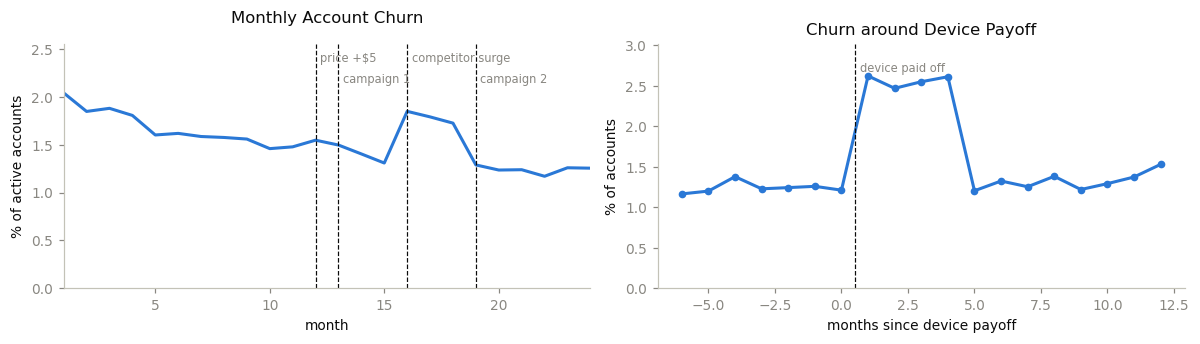

In [8]:
# Plot: Churn over Time & around Device Payoff
by_month = monthly_panel.groupby('month')['churned'].mean() * 100
payoff = monthly_panel.assign(since = monthly_panel['device_age'] - DEVICE_TERM)
by_payoff = payoff[payoff['since'].between(-6, 12)].groupby('since')['churned'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize = (11, 3.2))
axes[0].plot(by_month.index, by_month.values, color = ACCENT, linewidth = 2)
EVENTS = [(PRICE_INCREASE_MONTH, 'price +$5'), (CAMPAIGN_1_MONTH, 'campaign 1'), (SURGE_MONTHS[0], 'competitor surge'), (CAMPAIGN_2_MONTH, 'campaign 2')]
for i, (m, label) in enumerate(EVENTS):
    axes[0].axvline(m, color = INK, linewidth = 0.8, linestyle = '--')
    axes[0].text(m + 0.2, by_month.max() * (1.16 if i % 2 == 0 else 1.05), label, fontsize = 7.5, color = MUTED)
axes[0].set_ylim(0, by_month.max() * 1.25)
axes[0].set_xlim(1, N_MONTHS)
axes[0].set_title('Monthly Account Churn', pad = 14)
axes[0].set_ylabel('% of active accounts')
axes[0].set_xlabel('month')

axes[1].plot(by_payoff.index, by_payoff.values, color = ACCENT, linewidth = 2, marker = 'o', markersize = 4)
axes[1].axvline(0.5, color = INK, linewidth = 0.8, linestyle = '--')
axes[1].text(0.7, by_payoff.max() * 1.02, 'device paid off', fontsize = 7.5, color = MUTED)
axes[1].set_ylim(0, by_payoff.max() * 1.15)
axes[1].set_title('Churn around Device Payoff')
axes[1].set_xlabel('months since device payoff')
axes[1].set_ylabel('% of accounts')
plt.tight_layout()
plt.show()

## 6 · Scoring Snapshot & Future Months

**Purpose:** Freezes tonight's batch, every account still active at the end of month 24, and then keeps the world running for months 25–30 with no new offers. Those future months are withheld: Phase 7 releases them one month at a time to test monitoring.

**Design Notes:**

1. The snapshot holds only what the carrier knows on the scoring date: account fields, month-24 observables, 3-month summaries, and each account's most recent retention offer
2. The future months record every snapshot account's churn probability, even after it leaves in the simulation, because §7 needs each account's full path under every offer
3. From month 27 a competitor promotion runs in every region: the drift the monitoring should flag

In [9]:
# Build Scoring Snapshot & Simulate Future Months
def snapshot_features(panel, month):

    last3 = panel[panel['month'].between(month - 2, month)]
    summary = last3.groupby('account_id').agg(
        contacts_3m = ('care_contacts', 'sum'),
        throttle_days_3m = ('throttle_days', 'sum'),
        bill_change_3m_max = ('bill_change', 'max'),
        dropped_call_rate_3m = ('dropped_call_rate', 'mean'),
        late_payments_3m = ('late_payment', 'sum'),
    )
    current = panel[(panel['month'] == month) & ~panel['churned']].drop(columns = ['month', 'churned']).set_index('account_id')

    return current.join(summary).reset_index()


snapshot_ids = np.flatnonzero(active)
offers_made = campaigns.sort_values('month').groupby('account_id').last()
offers_made = offers_made[offers_made['arm'] != 'control']

scoring_snapshot = (snapshot_features(monthly_panel, N_MONTHS)
                    .merge(accounts[['account_id', 'region_id', 'plan', 'lines', 'join_month', 'autopay', 'do_not_contact']], on = 'account_id'))
scoring_snapshot.insert(1, 'tenure', N_MONTHS - scoring_snapshot['join_month'])
scoring_snapshot['last_offer_month'] = scoring_snapshot['account_id'].map(offers_made['month']).astype('Int64')
scoring_snapshot['last_offer'] = scoring_snapshot['account_id'].map(offers_made['arm'])
scoring_snapshot['last_offer_accepted'] = scoring_snapshot['account_id'].map(offers_made['accepted']).astype('boolean')
scoring_snapshot = scoring_snapshot.drop(columns = 'join_month')

promo_expired_m24 = state['promo_expired'].copy()
future_hazard = np.zeros((len(snapshot_ids), N_FUTURE))
future_active = active.copy()
future_parts = []
for k, month in enumerate(range(N_MONTHS + 1, N_MONTHS + N_FUTURE + 1)):
    obs, hazard = draw_month(month, state, RNG)
    base_hazard[:, month] = hazard
    log_context(month, obs)
    p = np.clip(hazard * multiplier[:, month], 0, 0.9)
    future_hazard[:, k] = p[snapshot_ids]
    leaves = future_active & (RNG.random(N_ACCOUNTS) < p)
    ids = np.flatnonzero(future_active)
    part = obs.iloc[ids].copy()
    part.insert(0, 'month', month)
    part.insert(0, 'account_id', ids)
    part['churned'] = leaves[ids]
    future_parts.append(part)
    future_active &= ~leaves

future_panel = pd.concat(future_parts, ignore_index = True)
print(f'scoring snapshot: {len(scoring_snapshot):,} accounts · future panel: {len(future_panel):,} account-months')
display(future_panel.groupby('month')['churned'].mean().mul(100).round(2).to_frame('churn %'))

scoring snapshot: 75,301 accounts · future panel: 435,578 account-months


,churn %
month,
25,1.21
26,1.17
27,1.89
28,1.86
29,1.89
30,1.82


## 7 · Potential Outcomes

**Purpose:** Computes, for every account in tonight's batch, the true probability of leaving within 90 days under each of the four arms, and its true 24-month value. This is the answer key the optimizer and the agent are scored against: any targeting policy can be valued exactly, without simulation noise. The same calculation for both past campaigns gives the true effect of each offer on the accounts that received it, which Phase 3 scores the uplift model against.

**Design Notes:**

1. Each offer's probability averages the accepted and not-accepted paths, weighted by the account's true acceptance rate
2. Sleeping dogs carry the contact penalty on both paths, since the contact itself is what prompts them to shop around
3. 24-month value is monthly margin (55% of the service bill) times the chance of still being a customer, discounted 1% a month; months 7–24 extend the average churn probability of months 4–6
4. For the campaigns, the 90 days after each offer fall outside the other campaign's effect window, so the untreated churn probability is simply the recorded one

In [10]:
# Compute Potential Outcomes
def churn_within(h, months = 3):

    return 1 - np.prod(1 - np.clip(h[:, :months], 0, 0.9), axis = 1)


def potential_outcomes(ids, hazards, month):
    """True 90-day churn under each arm, given each account's untreated monthly churn probabilities."""

    t = truth.set_index('account_id').loc[ids]
    reason, dog, frailty = t['reason'].to_numpy(), t['sleeping_dog'].to_numpy(), t['frailty'].to_numpy()
    plan = accounts['plan'].to_numpy()[ids]
    out = pd.DataFrame({'account_id': ids, 'p_churn_90_control': churn_within(hazards)})
    dog_factor = np.ones_like(hazards)
    dog_factor[dog, :SLEEPING_DOG_MONTHS] = SLEEPING_DOG_CONTACT
    for offer in OFFERS:
        m = offer_multipliers(offer, reason, plan, {k: v[ids, month] for k, v in context_log.items()})
        faded = np.column_stack([fade(m, k) for k in range(1, hazards.shape[1] + 1)])
        accept = accept_probability(offer, reason, dog, frailty)
        p_yes = churn_within(hazards * faded * dog_factor)
        p_no = churn_within(hazards * dog_factor)
        out[f'p_churn_90_{offer}'] = accept * p_yes + (1 - accept) * p_no
        out[f'accept_{offer}'] = accept

    return out


potential = potential_outcomes(snapshot_ids, future_hazard, N_MONTHS)

service_bill = list_bill(N_MONTHS)[snapshot_ids] * np.where(promo_expired_m24[snapshot_ids], 1.12, 1.0)
tail = np.repeat(future_hazard[:, 3:6].mean(axis = 1, keepdims = True), 24 - N_FUTURE, axis = 1)
path = np.column_stack([future_hazard, tail])
survival = np.cumprod(1 - path, axis = 1)
potential['clv_24m'] = (service_bill[:, None] * MARGIN_RATE * survival * 0.99 ** np.arange(1, 25)).sum(axis = 1).round(2)

campaign_truth = []
for (campaign, month), rows in campaigns.groupby(['campaign', 'month']):
    ids = rows['account_id'].to_numpy()
    hazards = base_hazard[ids, month + 1:month + 1 + EFFECT_MONTHS].astype(float)
    campaign_truth.append(potential_outcomes(ids, hazards, month).assign(campaign = campaign))
truth_campaign_outcomes = pd.concat(campaign_truth, ignore_index = True)

display(potential.drop(columns = 'account_id').describe().T[['mean', '50%', 'max']].round(4))

,mean,50%,max
p_churn_90_control,0.0427,0.0285,0.9551
p_churn_90_discount,0.0362,0.0224,0.9510
accept_discount,0.4949,0.4639,0.9000
p_churn_90_device,0.0383,0.0245,0.9510
accept_device,0.4026,0.3553,0.9000
p_churn_90_data,0.0410,0.0271,0.9477
accept_data,0.3129,0.3012,0.6996
clv_24m,1202.7445,1016.2200,4150.2800


## 8 · Care Notes

**Purpose:** Writes about 6,000 care notes with gpt-4o-mini, one per sampled care contact. Each prompt carries the account's hidden reason and a few account facts; the notes are what the NLP model reads to recover the reason, and what the agent retrieves when drafting outreach.

**Design Notes:**

1. Contacts are sampled mostly from months 13–24 and weighted toward accounts still active at month 24, so tonight's batch has notes to retrieve
2. 15% of notes are routine (address change, payment arrangement, adding a line, autopay). Of the rest, 30% are about some other issue than the account's hidden reason, because customers don't only call about what would make them leave, and 20% also mention a secondary issue, so topics overlap the way real notes do
3. The prompt describes the situation, never the category name, and asks for it in the model's own words. In half the notes the customer only hints at the real concern, so the reason has to be inferred
4. Notes are third person, like real care notes, at most 3 sentences and about 60 words, with no names, phone numbers, or account numbers
5. Notes are cached in `synthetic/care_notes_cache.parquet`. With the cache present the cell makes no API calls; without it, it needs `OPENAI_API_KEY` and takes about 10–15 minutes

In [11]:
# Sample Contacts & Build Note Prompts
REASON_BRIEF = {
    'price': 'unhappy with the size of the bill or a recent increase; may mention a cheaper offer seen elsewhere',
    'network': 'dropped calls or weak signal at home or work; frustrated that coverage has not improved',
    'device': 'phone is old, slow, or the battery dies quickly; asking about upgrade options',
    'service': 'frustrated that an earlier problem is still not fixed; has called before and been transferred or kept on hold',
    'relocation': 'moving to another city or state soon; asking whether coverage there is good or how to end service',
}
ROUTINE_TOPICS = ['updating a billing address', 'setting up a payment arrangement', 'adding a line for a family member', 'turning on autopay']
STYLES = ['clipped rep shorthand: sentence fragments and abbreviations such as cust, acct, w/, re:, no full sentences', 'short plain sentences, neutral and factual']

def tenure_band(months):
    return np.select([months < 12, months < 36], ['under 1 year', '1–3 years'], '3+ years')


month_weight = np.where(care_contacts['month'] >= CAMPAIGN_1_MONTH, 1.0, 0.15)
active_weight = np.where(np.isin(care_contacts['account_id'], snapshot_ids), 3.0, 1.0)
weights = month_weight * active_weight * (care_contacts['month'] >= 7)
sampled = care_contacts.iloc[RNG.choice(len(care_contacts), size = N_NOTES, replace = False, p = weights / weights.sum())]

note_spec = (sampled[['contact_id', 'account_id', 'month']]
             .merge(monthly_panel[['account_id', 'month', 'bill_change', 'dropped_call_rate', 'device_age']], on = ['account_id', 'month'])
             .merge(accounts[['account_id', 'plan', 'lines', 'join_month']], on = 'account_id')
             .merge(truth[['account_id', 'reason']], on = 'account_id')
             .sort_values('contact_id').reset_index(drop = True))
note_spec.insert(0, 'note_id', np.arange(len(note_spec)))
routine = RNG.random(len(note_spec)) < ROUTINE_NOTE_RATE
note_spec['routine_topic'] = np.where(routine, RNG.choice(ROUTINE_TOPICS, size = len(note_spec)), None)
note_spec['primary_reason'] = np.where(routine, None, note_spec['reason'])
others = np.array([RNG.choice([r for r in REASONS if r != reason]) for reason in note_spec['reason']])
note_spec['secondary_reason'] = np.where(~routine & (RNG.random(len(note_spec)) < SECONDARY_ISSUE_RATE), others, None)
note_spec['style'] = RNG.choice(STYLES, size = len(note_spec))
note_spec['hinted'] = ~routine & (RNG.random(len(note_spec)) < HINTED_NOTE_RATE)
off_topic = ~routine & (RNG.random(len(note_spec)) < OFF_TOPIC_NOTE_RATE)
other_topic = np.array([RNG.choice([r for r in REASONS[:4] if r != reason]) for reason in note_spec['reason']])
note_spec['account_reason'] = np.where(routine, None, note_spec['reason'])
note_spec['primary_reason'] = np.where(off_topic, other_topic, note_spec['primary_reason'])
note_spec['secondary_reason'] = np.where(note_spec['secondary_reason'] == note_spec['primary_reason'], None, note_spec['secondary_reason'])
note_spec['tenure_band'] = tenure_band(note_spec['month'] - note_spec['join_month'])


def note_prompt(row):

    facts = (f"Plan: {row['plan'].replace('_', ' ')}, {row['lines']} line(s). Customer for {row['tenure_band']}. "
             f"Phone is {row['device_age']} months old. Bill changed {row['bill_change']:+.0%} vs. recent months. "
             f"Dropped calls: {'high' if row['dropped_call_rate'] > 2.5 else 'normal'}.")
    if row['routine_topic']:
        situation = f"The customer contacted care about {row['routine_topic']}. Nothing else came up."
    else:
        situation = f"Underlying concern: {REASON_BRIEF[row['primary_reason']]}."
        if row['hinted']:
            situation += (" The customer never says this outright: they only hint at it, or ask a related question, "
                          "so the note records what they asked about rather than the concern itself.")
        if row['secondary_reason']:
            situation += f" They also briefly mentioned something else: {REASON_BRIEF[row['secondary_reason']]}."

    return (f"Write the internal note a care rep at a US wireless carrier logged after this contact. "
            f"{situation} Account facts the rep could see: {facts} "
            f"Style: {row['style']}. Third person (for example 'Cust called…', 'Rep reviewed…'), never 'I'. "
            f"At most 3 sentences and about 60 words. Say what the customer raised and what the rep did next. "
            f"Describe the situation in your own words, with concrete specifics of your choosing; don't reuse the wording above. "
            f"Mention account facts only if relevant. Do not name a category or label the reason. "
            f"No names, phone numbers, account numbers, or dates. Return only the note.")


note_spec['prompt'] = note_spec.apply(note_prompt, axis = 1)
print(f"{len(note_spec):,} notes · {routine.mean():.0%} routine · {off_topic.mean():.0%} about another issue · "
      f"{note_spec['secondary_reason'].notna().mean():.0%} with a secondary issue · {note_spec['hinted'].mean():.0%} hinted")
print(note_spec['prompt'].iloc[0])

6,000 notes · 14% routine · 25% about another issue · 16% with a secondary issue · 42% hinted
Write the internal note a care rep at a US wireless carrier logged after this contact. Underlying concern: phone is old, slow, or the battery dies quickly; asking about upgrade options. The customer never says this outright: they only hint at it, or ask a related question, so the note records what they asked about rather than the concern itself. They also briefly mentioned something else: dropped calls or weak signal at home or work; frustrated that coverage has not improved. Account facts the rep could see: Plan: 15gb, 2 line(s). Customer for 1–3 years. Phone is 44 months old. Bill changed +0% vs. recent months. Dropped calls: normal. Style: clipped rep shorthand: sentence fragments and abbreviations such as cust, acct, w/, re:, no full sentences. Third person (for example 'Cust called…', 'Rep reviewed…'), never 'I'. At most 3 sentences and about 60 words. Say what the customer raised and wha

In [12]:
# Generate or Load Care Notes
NOTES_CACHE = DATA / 'care_notes_cache.parquet'


def openai_key():

    if os.environ.get('OPENAI_API_KEY'):
        return os.environ['OPENAI_API_KEY']
    env_file = Path('../../../selected-work/.env')
    if env_file.exists():
        for line in env_file.read_text().splitlines():
            if line.strip().startswith('OPENAI_API_KEY'):
                return line.split('=', 1)[1].strip().strip('"\'')

    return None


def generate_notes(prompts):
    """Writes one note per prompt. Progress is saved every 500 notes, so an interrupted run resumes."""
    from concurrent.futures import ThreadPoolExecutor
    from openai import OpenAI

    client = OpenAI(api_key = openai_key(), max_retries = 12)
    partial = DATA / 'care_notes_partial.parquet'
    done = {}
    for saved in [NOTES_CACHE, partial]:
        if saved.exists():
            done.update(dict(pd.read_parquet(saved)[['prompt', 'text']].itertuples(index = False)))

    def one(prompt):
        response = client.chat.completions.create(
            model = NOTE_MODEL, temperature = 0.9, max_tokens = 120,
            messages = [{'role': 'user', 'content': prompt}])
        return response.choices[0].message.content.strip()

    wanted = list(dict.fromkeys(prompts))
    todo = [p for p in wanted if p not in done]
    print(f'{len(wanted) - len(todo):,} notes reused from earlier runs · {len(todo):,} to write')
    with ThreadPoolExecutor(max_workers = 8) as pool:
        for start in range(0, len(todo), 500):
            batch = todo[start:start + 500]
            done.update(zip(batch, pool.map(one, batch)))
            pd.DataFrame({'prompt': list(done), 'text': list(done.values())}).to_parquet(partial, index = False)
            print(f'{min(start + 500, len(todo)):,} of {len(todo):,} new notes written')

    partial.unlink()

    return [done[p] for p in prompts]


cache_ok = NOTES_CACHE.exists() and pd.read_parquet(NOTES_CACHE)['prompt'].equals(note_spec['prompt'])
if cache_ok:
    note_text = pd.read_parquet(NOTES_CACHE)['text']
    print(f'loaded {len(note_text):,} cached notes')
else:
    if openai_key() is None:
        raise RuntimeError('No cached notes match these settings and OPENAI_API_KEY is not set')
    note_text = pd.Series(generate_notes(note_spec['prompt'].tolist()))
    pd.DataFrame({'note_id': note_spec['note_id'], 'prompt': note_spec['prompt'], 'text': note_text, 'model': NOTE_MODEL}).to_parquet(NOTES_CACHE, index = False)
    print(f'cached {len(note_text):,} notes')

note_spec['text'] = note_text.to_numpy()
for _, row in note_spec.sample(4, random_state = 1).iterrows():
    print(f"[account: {row['account_reason'] or 'routine'} · note: {row['primary_reason'] or row['routine_topic']}] {row['text']}\n")

loaded 6,000 cached notes
[account: price · note: price] Cust called upset about bill increase of 16%, mentioned seeing cheaper offer elsewhere. Rep reviewed acct details, confirmed cust has unlimited plus plan, 1 line, with recent phone only 1 month old. Offered to go over bill breakdown and discuss plan options to lower costs, cust agreed to review available alternatives.

[account: service · note: service] Cust called expressing concern about recent bill increase and asked about the changes. Rep reviewed account details and confirmed the 24% increase was due to recent promotions expiring. Cust mentioned experiencing dropped calls and was advised to check network status; rep offered to investigate further and ensure ongoing issues are addressed.

[account: price · note: price] Cust called in asking about recent bill increase, noted it was 57% higher than last few months. Mentioned seeing lower prices from other carriers but didn’t directly express intent to switch. Rep reviewed acct 

## 9 · Offer Policy

**Purpose:** Writes the offer policy the agent retrieves from and must follow. It is short and split into one topic per section, so retrieval returns the rule that matters.

**Design Notes:**

1. Rules marked **(hard)** are also checked in code by the agent's compliance step; the rest are judged by the LLM reviewer
2. The eligibility thresholds match fields in the scoring snapshot, so every hard rule is checkable from data
3. The nightly budget is not here: it is a Phase 5 setting

In [13]:
# Write Offer Policy
OFFER_POLICY = """# Retention Offer Policy

Synthetic policy for the AI Customer Retention Agent case study. Offers and terms are illustrative.

## Offers and exact terms
- **Loyalty discount:** $10 off the monthly bill for 6 months.
- **Device upgrade credit:** a $200 credit toward a new phone on a 24-month installment plan.
- **Data upgrade:** a free upgrade to unlimited data for 6 months, for the 15 GB plan.
Describe an offer only with these terms. Never add, round, or combine offers.

## Eligibility: loyalty discount (hard)
- Customer for at least 6 months.
- No loyalty discount in the past 12 months.
- No more than one late payment in the past 3 months.

## Eligibility: device upgrade credit (hard)
- Current phone at least 18 months old.
- Phone paid off, or within 3 months of payoff.
- No late payment in the past 3 months.

## Eligibility: data upgrade (hard)
- 15 GB plan only.

## Contact rules (hard)
- At most one retention offer per account in any 90 days.
- Never contact an account marked do-not-contact.
- One offer per message.
- SMS messages are at most 320 characters and end with "Reply STOP to opt out."

## Message standards
- State the offer and its terms exactly, in plain language.
- Friendly and direct. No deadlines, countdowns, or pressure.
- Never mention churn, risk scores, predictions, or "we noticed you might leave."
- Never name a competitor.
- Don't reference details the customer didn't share with us, such as usage patterns, unless they're on the bill.

## Escalation (hard)
- If the account has an unresolved support ticket, route it to a care follow-up instead of sending an offer.
- If the customer's contacts show a move out of the coverage area, don't send an offer.
- A complaint about the bill or price is not a reason to withhold an offer: it is what the offers are for.
"""

(DATA / 'offer_policy.md').write_text(OFFER_POLICY, encoding = 'utf-8')
print(f"offer_policy.md · {OFFER_POLICY.count('## ')} sections")

offer_policy.md · 7 sections


## 10 · Export

**Purpose:** Writes the model-facing tables and the withheld answer key as separate files. Modeling notebooks load through `retention.data.load()`, which refuses the answer key.

**Design Notes:**

1. Model-facing tables hold only what a carrier would have: no hidden reason, frailty, sleeping-dog flag, true acceptance rate, or future months
2. The account table drops the generator's per-account usage and network offsets, which are latent
3. `generator_parameters` is answer key too: it contains the true offer effects

In [14]:
# Export Tables
accounts_out = accounts.drop(columns = ['usage_offset', 'dropped_call_offset', 'device_purchase_month'])
contacts_out = care_contacts.merge(note_spec[['contact_id', 'note_id']], on = 'contact_id', how = 'left')
contacts_out['note_id'] = contacts_out['note_id'].astype('Int64')
care_notes = note_spec[['note_id', 'account_id', 'month', 'text']]
truth_notes = note_spec[['note_id', 'account_reason', 'primary_reason', 'secondary_reason', 'routine_topic', 'style', 'hinted']]
truth_accounts = truth.assign(churned_month = churned_month)

PARAMETERS = {k: v for k, v in globals().items() if k.isupper() and not k.startswith('_')
              and isinstance(v, (int, float, str, list, dict, pd.DataFrame, np.ndarray))
              and k not in {'OFFER_POLICY'}}
generator_parameters = pd.DataFrame({'name': list(PARAMETERS), 'value': [
    v.to_json() if isinstance(v, pd.DataFrame) else str(v.tolist() if isinstance(v, np.ndarray) else v) for v in PARAMETERS.values()]})

TABLES = {
    'accounts': accounts_out, 'monthly_panel': monthly_panel, 'care_contacts': contacts_out,
    'care_notes': care_notes, 'campaigns': campaigns, 'scoring_snapshot': scoring_snapshot,
    'truth_accounts': truth_accounts, 'truth_potential_outcomes': potential, 'truth_campaign_outcomes': truth_campaign_outcomes,
    'truth_notes': truth_notes,
    'future_panel': future_panel, 'generator_parameters': generator_parameters,
}
assert set(TABLES) == set(retention_data.MODEL_TABLES) | set(retention_data.ANSWER_KEY_TABLES)
for name, table in TABLES.items():
    table.to_parquet(DATA / f'{name}.parquet', index = False)

display(pd.DataFrame({
    'rows': {n: len(t) for n, t in TABLES.items()},
    'answer key': {n: n in retention_data.ANSWER_KEY_TABLES for n in TABLES},
}))

,rows,answer key
accounts,104700,False
monthly_panel,1896977,False
care_contacts,216854,False
care_notes,6000,False
campaigns,50000,False
scoring_snapshot,75301,False
truth_accounts,104700,True
truth_potential_outcomes,75301,True
truth_campaign_outcomes,50000,True
truth_notes,6000,True


---
# Part 2 · Validating the Synthetic Data

1. Confirm the generated account base behaves like a plausible postpaid carrier before anything is fitted
2. Confirm each structure the modeling notebooks are meant to find is present, and not trivially easy to find
3. Each check has a target from [generator_design.md](generator_design.md); a failure means tuning Part 1, not adjusting the target

The checks run on the exported files, reloaded through `retention.data`, so they test what the modeling notebooks will actually see.

In [15]:
# Reload Exported Tables
panel = retention_data.load('monthly_panel')
camps = retention_data.load('campaigns')
snapshot = retention_data.load('scoring_snapshot')
notes = retention_data.load('care_notes')
truth_acc = retention_data.load_answer_key('truth_accounts').set_index('account_id')
outcomes = retention_data.load_answer_key('truth_potential_outcomes').set_index('account_id')
truth_nt = retention_data.load_answer_key('truth_notes').set_index('note_id')
truth_camp = retention_data.load_answer_key('truth_campaign_outcomes')

CHECKS = []

def record(number, check, value, target, passed):
    CHECKS.append({'#': number, 'check': check, 'value': value, 'target': target, 'pass': bool(passed)})
    print(f"{'PASS' if passed else 'FAIL'} · {check}: {value} (target {target})")

print(f'{len(panel):,} account-months · {len(snapshot):,} accounts in tonight\'s batch · {len(notes):,} notes')

1,896,977 account-months · 75,301 accounts in tonight's batch · 6,000 notes


---
## 1 · Churn Rate & Timing

**Purpose:** Confirms the overall churn rate is plausible for postpaid wireless and that the timing effects the survival model should find are visible: higher churn in the first year, and a jump after the device is paid off.

**Design Notes:**

1. Target 1.1–1.6% of accounts a month
2. First-year churn should clearly exceed churn after three years
3. Churn in the 4 months after payoff should exceed the 4 months before it

In [16]:
# Check Churn Rate & Timing
tenure = panel['month'] - panel['account_id'].map(retention_data.load('accounts').set_index('account_id')['join_month'])
by_tenure = panel.groupby(pd.cut(tenure, [-1, 11, 35, 999], labels = ['under 1 year', '1–3 years', '3+ years']), observed = True)['churned'].mean()
since = panel['device_age'] - DEVICE_TERM
before, after = panel.loc[since.between(-3, 0), 'churned'].mean(), panel.loc[since.between(1, 4), 'churned'].mean()

monthly = panel['churned'].mean()
record(1, 'Monthly churn rate', f'{monthly:.2%}', '1.1–1.6%', 0.011 <= monthly <= 0.016)
record(1, 'First-year vs 3+ year churn', f"{by_tenure.iloc[0]:.2%} vs {by_tenure.iloc[-1]:.2%}", 'first year higher', by_tenure.iloc[0] > 1.3 * by_tenure.iloc[-1])
record(1, 'Churn after vs before payoff', f'{after:.2%} vs {before:.2%}', 'after higher', after > 1.2 * before)

PASS · Monthly churn rate: 1.55% (target 1.1–1.6%)
PASS · First-year vs 3+ year churn: 2.49% vs 1.34% (target first year higher)
PASS · Churn after vs before payoff: 2.56% vs 1.24% (target after higher)


---
## 2 · Campaign 1 Balance

**Purpose:** Confirms the randomized campaign really is randomized: each offer arm looks like the control arm on everything observable at month 13. If it didn't, the uplift model would learn targeting, not effects.

**Design Notes:**

1. Standardized mean difference (difference in means over the pooled standard deviation) for each arm against control
2. Target: every difference below 0.1, the usual rule of thumb; with about 3,200 accounts an arm, chance alone produces differences near 0.05

In [17]:
# Check Campaign 1 Balance
c1 = camps[camps['campaign'] == 'campaign_1'].merge(panel[panel['month'] == CAMPAIGN_1_MONTH], on = 'account_id')
BALANCE_FIELDS = ['bill', 'bill_change', 'data_gb', 'dropped_call_rate', 'care_contacts', 'device_age', 'months_to_payoff']

def smd(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

control = c1[c1['arm'] == 'control']
balance = pd.DataFrame({arm: {f: smd(c1.loc[c1['arm'] == arm, f].astype(float), control[f].astype(float)) for f in BALANCE_FIELDS} for arm in OFFERS})
display(balance.round(3))
worst = balance.abs().to_numpy().max()
record(2, 'Campaign 1 largest standardized difference', f'{worst:.3f}', '< 0.1', worst < 0.1)

,discount,device,data
bill,0.006,0.022,-0.009
bill_change,-0.002,-0.024,-0.004
data_gb,-0.004,0.008,0.004
dropped_call_rate,0.005,0.005,0.010
care_contacts,-0.022,-0.006,-0.009
device_age,-0.013,-0.003,0.004
months_to_payoff,0.018,0.003,-0.004


PASS · Campaign 1 largest standardized difference: 0.024 (target < 0.1)


---
## 3 · Average Offer Effects

**Purpose:** Confirms each offer lowers churn on average by a realistic amount, and that campaign 1 is large enough to detect the main one. Too large and the problem is trivial; too small and the uplift model has nothing to learn from.

**Design Notes:**

1. Outcome: leaving within 90 days of the offer (months 14–16)
2. True effect: the answer key's average over all campaign 1 accounts, free of sampling noise. Targets: discount 10–25% lower churn; device credit 8–20%, since it only works fully near payoff; data upgrade 1–10%, since it only fits the 15 GB plan
3. Learnability: what Phase 3 needs is not the average effect but who responds. An analyst's segment estimate (control minus offer churn within cells of a few observables, from 70% of campaign 1) ranks the other 30%; averaged over 5 splits, the true uplift of its top fifth should be at least 1.5× the average for the discount and the device credit. An oracle reaches about 4×

In [18]:
# Check Average Offer Effects
left = panel[panel['month'].between(CAMPAIGN_1_MONTH + 1, CAMPAIGN_1_MONTH + 3)].groupby('account_id')['churned'].any()
c1_out = camps[camps['campaign'] == 'campaign_1'].assign(churn_90 = lambda d: d['account_id'].map(left).fillna(False).astype(bool))
rates = c1_out.groupby('arm')['churn_90'].agg(['mean', 'size']).reindex(ARMS)
p0, n0 = rates.loc['control']
effects = []
for offer in OFFERS:
    p1, n1 = rates.loc[offer]
    z = (p0 - p1) / np.sqrt(p0 * (1 - p0) / n0 + p1 * (1 - p1) / n1)
    effects.append({'offer': offer, 'churn_90': p1, 'control': p0, 'relative_reduction': 1 - p1 / p0, 'z': z,
                    'accepted': c1_out.loc[c1_out['arm'] == offer, 'accepted'].mean()})
effects = pd.DataFrame(effects).set_index('offer')
c1_truth = truth_camp[truth_camp['campaign'] == 'campaign_1']
effects['true_reduction'] = [1 - c1_truth[f'p_churn_90_{o}'].mean() / c1_truth['p_churn_90_control'].mean() for o in OFFERS]
display(effects.style.format({'churn_90': '{:.2%}', 'control': '{:.2%}', 'relative_reduction': '{:.0%}', 'z': '{:.2f}', 'accepted': '{:.0%}', 'true_reduction': '{:.0%}'}))
for offer, (low, high) in {'discount': (0.10, 0.25), 'device': (0.08, 0.20), 'data': (0.01, 0.10)}.items():
    r = effects.loc[offer, 'true_reduction']
    record(3, f'True {offer} effect', f'{r:.0%} lower churn', f'{low:.0%}–{high:.0%}', low <= r <= high)

,churn_90,control,relative_reduction,z,accepted,true_reduction
offer,,,,,,
discount,3.61%,4.55%,21%,3.54,49%,19%
device,3.97%,4.55%,13%,2.09,40%,10%
data,4.47%,4.55%,2%,0.28,31%,4%


PASS · True discount effect: 19% lower churn (target 10%–25%)
PASS · True device effect: 10% lower churn (target 8%–20%)
PASS · True data effect: 4% lower churn (target 1%–10%)


In [19]:
# Check Uplift Learnability
contacts_mf = retention_data.load('care_contacts')
recent_codes = contacts_mf[contacts_mf['month'].between(CAMPAIGN_1_MONTH - 5, CAMPAIGN_1_MONTH)]
codes = pd.crosstab(recent_codes['account_id'], recent_codes['reason_code']).clip(upper = 1)
window = panel[panel['month'].between(CAMPAIGN_1_MONTH - 2, CAMPAIGN_1_MONTH)].groupby('account_id').agg(
    bill_change_3m = ('bill_change', 'max'), promo_3m = ('competitor_promo', 'max'))
at_offer = panel[panel['month'] == CAMPAIGN_1_MONTH].set_index('account_id')[['months_to_payoff', 'device_age']]
cells = c1_out.set_index('account_id').join(window).join(at_offer).join(codes).fillna(0)
cells['price_pressure'] = (cells['bill_change_3m'] > 0.05) | (cells['promo_3m'] > 0.4)
cells['near_payoff'] = cells['months_to_payoff'] <= 3
cells['old_device'] = cells['device_age'] >= 30
SEGMENTS = {'discount': ['price_pressure', 'billing', 'service'], 'device': ['near_payoff', 'old_device', 'device']}
c1_true = c1_truth.set_index('account_id')

learnability = []
for split in range(5):
    held_out = np.random.default_rng(split).random(len(cells)) < 0.3
    for offer, keys in SEGMENTS.items():
        train = cells[~held_out & cells['arm'].isin(['control', offer])]
        rates = train.groupby(keys + ['arm'])['churn_90'].mean().unstack('arm')
        estimate = (rates['control'] - rates[offer]).rename('estimate')
        scored = cells[held_out].join(estimate, on = keys)
        true = (c1_true['p_churn_90_control'] - c1_true[f'p_churn_90_{offer}']).loc[scored.index]
        top = scored['estimate'].rank(ascending = False, method = 'first') <= len(scored) / 5
        oracle = true.sort_values(ascending = False).iloc[:len(true) // 5].mean()
        learnability.append({'split': split, 'offer': offer, 'segments': true[top].mean() / true.mean(), 'oracle': oracle / true.mean()})

learnability = pd.DataFrame(learnability).groupby('offer')[['segments', 'oracle']].agg(['mean', 'min'])
display(learnability.round(2))
for offer in SEGMENTS:
    lift = learnability.loc[offer, ('segments', 'mean')]
    record(3, f'Learnable {offer} uplift, top fifth vs average', f'{lift:.1f}×', '≥ 1.5×', lift >= 1.5)

segments       oracle      
             mean   min   mean   min
offer                               
device       1.58  0.13   4.42  4.40
discount     1.85  1.69   4.11  4.09

PASS · Learnable discount uplift, top fifth vs average: 1.9× (target ≥ 1.5×)
PASS · Learnable device uplift, top fifth vs average: 1.6× (target ≥ 1.5×)


---
## 4 · Effect Heterogeneity

**Purpose:** Confirms offer effects differ enough between customers to be worth modeling, and that some customers are harmed by contact. This is what separates uplift targeting from giving everyone the same offer.

**Design Notes:**

1. Uplift = true 90-day churn under control minus under the offer, from the answer key for tonight's batch
2. Best-offer uplift = the largest of the three, which is what an ideal policy would use
3. Targets: top-decile best-offer uplift at least 3× the average; about 10% of accounts harmed by the discount (5–15%)

In [20]:
# Check Effect Heterogeneity
uplift = pd.DataFrame({o: outcomes['p_churn_90_control'] - outcomes[f'p_churn_90_{o}'] for o in OFFERS})
best_uplift = uplift.max(axis = 1)
top_decile = best_uplift[best_uplift >= best_uplift.quantile(0.9)].mean()
harmed = (uplift['discount'] < 0).mean()
display(uplift.join(truth_acc['reason']).groupby('reason').mean().reindex(REASONS).mul(100).round(2).rename_axis('uplift, points'))
record(4, 'Top-decile vs average best-offer uplift', f'{top_decile / best_uplift.mean():.1f}×', '≥ 3×', top_decile >= 3 * best_uplift.mean())
record(4, 'Accounts harmed by the discount', f'{harmed:.1%}', '5–15%', 0.05 <= harmed <= 0.15)

,discount,device,data
"uplift, points",,,
price,1.47,0.32,0.40
network,-0.01,-0.01,0.05
device,0.01,1.46,-0.01
service,0.55,0.16,0.07
relocation,-0.13,-0.13,-0.13


PASS · Top-decile vs average best-offer uplift: 5.2× (target ≥ 3×)
PASS · Accounts harmed by the discount: 10.7% (target 5–15%)


---
## 5 · The Built-In Finding

**Purpose:** Confirms the finding the case study rests on: the customers most likely to leave are often not the ones an offer can keep. It compares two ideal policies that both know the answer key, so the gap is a property of the data, not of any model.

**Design Notes:**

1. Both policies spend the same expected budget, $40,000 (offer cost × acceptance rate), skip do-not-contact accounts, and give each chosen customer its best offer
2. **Risk first** contacts customers in order of true churn risk. **Uplift first** contacts them in order of customers saved per expected dollar
3. Targets: risk and best-offer uplift only moderately related (rank correlation ≤ 0.5); uplift first saves at least 30% more customers

In [21]:
# Check the Built-In Finding
BUDGET = 40_000

def ideal_policy(order_by):

    table = outcomes.join(snapshot.set_index('account_id')['do_not_contact'])
    table = table[~table['do_not_contact']].copy()
    table['best'] = uplift.loc[table.index].idxmax(axis = 1)
    table['saved'] = uplift.loc[table.index].max(axis = 1)
    table['cost'] = [table.at[i, f'accept_{o}'] * OFFER_COST[o] for i, o in zip(table.index, table['best'])]
    key = table['p_churn_90_control'] if order_by == 'risk' else table['saved'] / table['cost']
    table = table.loc[key.sort_values(ascending = False).index]
    chosen = table[table['cost'].cumsum() <= BUDGET]

    return {'customers contacted': len(chosen), 'customers saved': chosen['saved'].sum(),
            'net value': (chosen['saved'] * chosen['clv_24m']).sum() - chosen['cost'].sum()}


rho = pd.Series(outcomes['p_churn_90_control']).rank().corr(best_uplift.rank())
policies = pd.DataFrame({'risk first': ideal_policy('risk'), 'uplift first': ideal_policy('uplift')}).T
display(policies.style.format({'customers contacted': '{:,.0f}', 'customers saved': '{:,.1f}', 'net value': '${:,.0f}'}))
gain = policies.loc['uplift first', 'customers saved'] / policies.loc['risk first', 'customers saved'] - 1
record(5, 'Rank correlation, risk vs best-offer uplift', f'{rho:.2f}', '≤ 0.5', rho <= 0.5)
record(5, 'Uplift first vs risk first, customers saved', f'+{gain:.0%}', '≥ +30%', gain >= 0.30)

,customers contacted,customers saved,net value
risk first,"1,670",52.8,"$-5,472"
uplift first,"1,208",86.2,"$18,134"


PASS · Rank correlation, risk vs best-offer uplift: 0.48 (target ≤ 0.5)
PASS · Uplift first vs risk first, customers saved: +63% (target ≥ +30%)


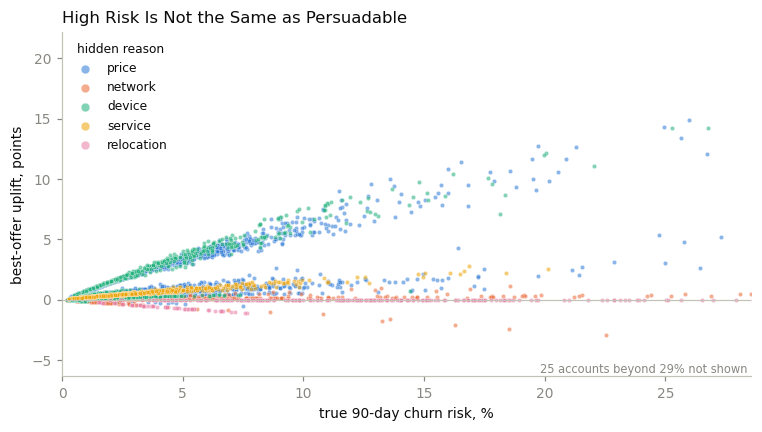

In [22]:
# Plot: Churn Risk vs Offer Uplift
sample = outcomes.join(truth_acc['reason']).assign(uplift = best_uplift).sample(5_000, random_state = 7)
fig, ax = plt.subplots(figsize = (7, 4))
for reason in REASONS:
    s = sample[sample['reason'] == reason]
    ax.scatter(s['p_churn_90_control'] * 100, s['uplift'] * 100, s = 8, alpha = 0.55, color = REASON_COLORS[reason],
               edgecolor = SURFACE, linewidth = 0.3, label = reason)
ax.axhline(0, color = BASELINE, linewidth = 0.8)
x_max = sample['p_churn_90_control'].quantile(0.995) * 100
ax.set_xlim(0, x_max)
ax.text(x_max, ax.get_ylim()[0], f'{(sample["p_churn_90_control"] * 100 > x_max).sum()} accounts beyond {x_max:.0f}% not shown ',
        ha = 'right', va = 'bottom', fontsize = 7.5, color = MUTED)
ax.set_xlabel('true 90-day churn risk, %')
ax.set_ylabel('best-offer uplift, points')
ax.set_title('High Risk Is Not the Same as Persuadable', loc = 'left')
ax.legend(frameon = False, fontsize = 8, title = 'hidden reason', title_fontsize = 8, markerscale = 2)
plt.tight_layout()
plt.show()

---
## 6 · Campaign 2 Confounding

**Purpose:** Confirms the targeted campaign would mislead anyone who analyzed it naively. Because it targeted customers already more likely to leave, simply comparing them with everyone else understates, or even reverses, the discount's true effect.

**Design Notes:**

1. Naive estimate: 90-day churn of contactable accounts not targeted, minus that of campaign 2 discount recipients
2. True effect: the answer key's average effect of the discount on the accounts that actually received it
3. Target: the naive estimate misses the true effect by at least half of it

In [23]:
# Check Campaign 2 Confounding
left_2 = panel[panel['month'].between(CAMPAIGN_2_MONTH + 1, CAMPAIGN_2_MONTH + 3)].groupby('account_id')['churned'].any()
at_19 = panel[panel['month'] == CAMPAIGN_2_MONTH].merge(retention_data.load('accounts')[['account_id', 'do_not_contact']], on = 'account_id')
at_19 = at_19[~at_19['churned'] & ~at_19['do_not_contact']]
c2 = camps[camps['campaign'] == 'campaign_2']
treated = at_19['account_id'].isin(c2.loc[c2['arm'] == 'discount', 'account_id'])
untargeted = ~at_19['account_id'].isin(c2['account_id'])
churn_2 = at_19['account_id'].map(left_2).fillna(False).astype(bool)

naive = churn_2[untargeted].mean() - churn_2[treated].mean()
c2_truth = truth_camp[(truth_camp['campaign'] == 'campaign_2') & truth_camp['account_id'].isin(c2.loc[c2['arm'] == 'discount', 'account_id'])]
true_effect = (c2_truth['p_churn_90_control'] - c2_truth['p_churn_90_discount']).mean()
miss = abs(naive - true_effect) / true_effect
print(f'naive discount effect: {naive * 100:+.2f} points · true effect on recipients: {true_effect * 100:+.2f} points')
record(6, 'Naive campaign 2 estimate misses the true effect by', f'{miss:.0%}', '≥ 50%', miss >= 0.5)

naive discount effect: +0.39 points · true effect on recipients: +0.89 points
PASS · Naive campaign 2 estimate misses the true effect by: 56% (target ≥ 50%)


---
## 7 · Notes Carry Signal

**Purpose:** Confirms the notes reveal the hidden reason, but not perfectly. If a simple classifier read them perfectly, the NLP phase would be trivial; if it couldn't read them at all, it would have nothing to find.

**Design Notes:**

1. TF-IDF on words and word pairs, then logistic regression, 5-fold cross-validated, on non-routine notes
2. The note's own topic should be easy to read; the account's hidden reason should not, because about 30% of notes are about some other issue
3. Target: 60–80% accuracy predicting the account's hidden reason (chance is about 35%)

In [24]:
# Check Notes Carry Signal
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

labeled = notes.set_index('note_id').join(truth_nt)
labeled = labeled[labeled['account_reason'].notna()]
text_model = make_pipeline(TfidfVectorizer(ngram_range = (1, 2), min_df = 2), LogisticRegression(max_iter = 2000))
accuracy = cross_val_score(text_model, labeled['text'], labeled['account_reason'], cv = 5).mean()
topic_accuracy = cross_val_score(text_model, labeled['text'], labeled['primary_reason'], cv = 5).mean()
print(f'note topic recovered: {topic_accuracy:.0%} · account reason recovered: {accuracy:.0%}')
record(7, 'Hidden reason recovered from notes', f'{accuracy:.0%}', '60–80%', 0.60 <= accuracy <= 0.80)

note topic recovered: 95% · account reason recovered: 67%
PASS · Hidden reason recovered from notes: 67% (target 60–80%)


---
## 8 · No Leakage

**Purpose:** Confirms nothing from the answer key reached the model-facing tables, and that the loader refuses the answer key.

**Design Notes:**

1. No model-facing table has a hidden field: reason, frailty, sleeping dog, acceptance rate, or a potential outcome
2. `load()` must raise for every answer-key table

In [25]:
# Check No Leakage
HIDDEN = {'reason', 'frailty', 'sleeping_dog', 'account_reason', 'primary_reason', 'secondary_reason', 'routine_topic', 'clv_24m'} | {c for c in outcomes.columns if c.startswith(('p_churn_90', 'accept_'))}
leaks = {name: sorted(HIDDEN & set(retention_data.load(name).columns)) for name in retention_data.MODEL_TABLES}
refused = []
for name in retention_data.ANSWER_KEY_TABLES:
    try:
        retention_data.load(name)
    except PermissionError:
        refused.append(name)
record(8, 'Hidden fields in model-facing tables', sum(map(len, leaks.values())), '0', not any(leaks.values()))
record(8, 'Answer-key tables refused by load()', f'{len(refused)} of {len(retention_data.ANSWER_KEY_TABLES)}', 'all', len(refused) == len(retention_data.ANSWER_KEY_TABLES))

PASS · Hidden fields in model-facing tables: 0 (target 0)
PASS · Answer-key tables refused by load(): 6 of 6 (target all)


---
## Summary

In [26]:
# Summarize Checks
summary = pd.DataFrame(CHECKS)
display(summary.style.hide(axis = 'index'))
print(f"{summary['pass'].sum()} of {len(summary)} checks pass")

#,check,value,target,pass
1,Monthly churn rate,1.55%,1.1–1.6%,True
1,First-year vs 3+ year churn,2.49% vs 1.34%,first year higher,True
1,Churn after vs before payoff,2.56% vs 1.24%,after higher,True
2,Campaign 1 largest standardized difference,0.024,< 0.1,True
3,True discount effect,19% lower churn,10%–25%,True
3,True device effect,10% lower churn,8%–20%,True
3,True data effect,4% lower churn,1%–10%,True
3,"Learnable discount uplift, top fifth vs average",1.9×,≥ 1.5×,True
3,"Learnable device uplift, top fifth vs average",1.6×,≥ 1.5×,True
4,Top-decile vs average best-offer uplift,5.2×,≥ 3×,True


17 of 17 checks pass
